# Smart Inventory Risk Prediction and Decision Support System
### Retailers often face two costly problems:

Stockouts → Lost sales and unhappy customers.<br>
Overstocking → Increased storage costs and wasted inventory.<br>

Most businesses react after these problems occur. Instead, this project aims to predict future demand and proactively identify inventory risks, allowing managers to make informed restocking decisions.

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading Dataset

In [2]:
df = pd.read_csv('Retail_Inventory_ML_Dataset.csv')
df.head()

,Date,Product_ID,Product_Name,Category,Warehouse,Supplier,Current_Stock,Reorder_Point,Safety_Stock,Lead_Time_Days,Units_Sold,Unit_Price,Promotion,Holiday,Season,Supplier_Reliability
0,2025-01-01,P001,Smartphone X,Electronics,WH001,SUP007,630.0,240.0,140,5.0,30,800,No,No,Winter,0.97
1,2025-01-02,P001,Smartphone X,Electronics,WH001,SUP007,604.0,240.0,140,5.0,26,800,No,No,Winter,0.97
2,2025-01-03,P001,Smartphone X,Electronics,WH001,SUP007,577.0,240.0,140,5.0,27,800,No,No,Winter,0.97
3,2025-01-04,P001,Smartphone X,Electronics,WH001,SUP007,543.0,240.0,140,5.0,34,800,No,No,Winter,0.97
4,2025-01-05,P001,Smartphone X,Electronics,WH001,SUP007,488.0,240.0,140,5.0,55,800,Yes,No,Winter,0.97


In [3]:
df.shape

(18250, 16)

In [4]:
df.dtypes

Date                     object
Product_ID               object
Product_Name             object
Category                 object
Warehouse                object
Supplier                 object
Current_Stock           float64
Reorder_Point           float64
Safety_Stock              int64
Lead_Time_Days          float64
Units_Sold                int64
Unit_Price                int64
Promotion                object
Holiday                  object
Season                   object
Supplier_Reliability    float64
dtype: object

## Data Cleaning and Preprocessing

### 1. Handling Dupplicates

In [5]:
df.duplicated().sum()

np.int64(8)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(18242, 16)

### 2. Handling Null Values

In [8]:
df.isnull().sum()

Date                      0
Product_ID                0
Product_Name              0
Category                  0
Warehouse                 0
Supplier                725
Current_Stock           860
Reorder_Point           808
Safety_Stock              0
Lead_Time_Days          610
Units_Sold                0
Unit_Price                0
Promotion               832
Holiday                   0
Season                    0
Supplier_Reliability    854
dtype: int64

### Converting Date to Datetime

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

### Fillning null values in  Promotion

In [10]:
df['Promotion'].value_counts()

Promotion
No     14780
Yes     2630
Name: count, dtype: int64

In [11]:
promotion_probs = df['Promotion'].value_counts(normalize=True)
promotion_probs

Promotion
No     0.848937
Yes    0.151063
Name: proportion, dtype: float64

In [12]:
null_indices = df[df['Promotion'].isnull()].index

df.loc[null_indices, 'Promotion'] = np.random.choice(a=promotion_probs.index, size=len(null_indices), p=promotion_probs.values)

### Filling Missing Values of Supplier

In [13]:
df['Supplier'] = df['Supplier'].fillna('Unknown')

### Imputing Current Stock

In [14]:
df['Current_Stock'] = df['Current_Stock'].fillna(
    df.groupby('Category')['Current_Stock'].transform('median'))

### Imputing Lead Time Days

In [15]:
df['Lead_Time_Days'] = df['Lead_Time_Days'].fillna(
    df.groupby('Supplier')['Lead_Time_Days'].transform('median'))

df['Lead_Time_Days'] = df['Lead_Time_Days'].fillna(df['Lead_Time_Days'].median())

### Imputing Reorder Point

In [16]:
df['Reorder_Point'] = df['Reorder_Point'].fillna(
    df.groupby('Product_ID')['Reorder_Point'].transform('median'))

### Imputing Supplier Reliability

In [17]:
df['Supplier_Reliability'] = df['Supplier_Reliability'].fillna(
    df.groupby('Supplier')['Supplier_Reliability'].transform('mean'))

In [18]:
df.isnull().sum()

Date                    0
Product_ID              0
Product_Name            0
Category                0
Warehouse               0
Supplier                0
Current_Stock           0
Reorder_Point           0
Safety_Stock            0
Lead_Time_Days          0
Units_Sold              0
Unit_Price              0
Promotion               0
Holiday                 0
Season                  0
Supplier_Reliability    0
dtype: int64

## Feature Engineering

In [19]:
# 1. Days of Supply / Stock Coverage Ratio
df['Days_of_Supply'] = np.where(df['Units_Sold']>0, df['Current_Stock']/df['Units_Sold'],0)

In [20]:
# 2. Stockout Indicator (Current Stock is below Reorder Point)
df['Is_Reorder_Needed'] = (df['Current_Stock'] <= df['Reorder_Point']).astype(int)

In [21]:
# 3. Buffer Stock Margin
df['Stock_Buffer'] = df['Current_Stock'] - df['Safety_Stock']

In [22]:
# 4. Extract Time Features from Date
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

In [23]:
def calculate_inventory_risk(row):
    risk = 0
    # Current stock
    if row['Current_Stock'] < row['Reorder_Point']:
        risk += 30

    # Safety stock
    if row['Current_Stock'] < row['Safety_Stock']:
        risk += 20

    # Lead time
    if row['Lead_Time_Days'] > 10:
        risk += 15
    elif row['Lead_Time_Days'] > 5:
        risk += 8

    # Days of Supply
    if row['Days_of_Supply'] < 7:
        risk += 20
    elif row['Days_of_Supply'] < 15:
        risk += 10

    # Supplier Reliability
    if row['Supplier_Reliability'] < 80:
        risk += 10
    elif row['Supplier_Reliability'] < 90:
        risk += 5

    # Promotion
    if row['Promotion'] == 1:
        risk += 5

    # Holiday
    if row['Holiday'] == 1:
        risk += 5

    # Peak season
    if row['Season'] in ['Festival', 'Winter']:
        risk += 5

    # Stock Buffer
    if row['Stock_Buffer'] < 50:
        risk += 10
    return risk

df['Risk_Score'] = df.apply(calculate_inventory_risk, axis=1)

In [24]:
def inventory_risk(score):
    if score < 30:
        return "Low Risk"
    elif score < 60:
        return "Medium Risk"
    else:
        return "High Risk"

df["Inventory_Risk"] = df["Risk_Score"].apply(inventory_risk)

In [25]:
df.head()

,Date,Product_ID,Product_Name,Category,Warehouse,Supplier,Current_Stock,Reorder_Point,Safety_Stock,Lead_Time_Days,...,Season,Supplier_Reliability,Days_of_Supply,Is_Reorder_Needed,Stock_Buffer,Month,DayOfWeek,Is_Weekend,Risk_Score,Inventory_Risk
0,2025-01-01,P001,Smartphone X,Electronics,WH001,SUP007,630.0,240.0,140,5.0,...,Winter,0.97,21.000000,0,490.0,1,2,0,15,Low Risk
1,2025-01-02,P001,Smartphone X,Electronics,WH001,SUP007,604.0,240.0,140,5.0,...,Winter,0.97,23.230769,0,464.0,1,3,0,15,Low Risk
2,2025-01-03,P001,Smartphone X,Electronics,WH001,SUP007,577.0,240.0,140,5.0,...,Winter,0.97,21.370370,0,437.0,1,4,0,15,Low Risk
3,2025-01-04,P001,Smartphone X,Electronics,WH001,SUP007,543.0,240.0,140,5.0,...,Winter,0.97,15.970588,0,403.0,1,5,1,15,Low Risk
4,2025-01-05,P001,Smartphone X,Electronics,WH001,SUP007,488.0,240.0,140,5.0,...,Winter,0.97,8.872727,0,348.0,1,6,1,25,Low Risk


## Exploratory Data Analysis

### Seperating Numerical and Categorical Columns

In [26]:
cat_cols = df.dtypes[df.dtypes=='object'].index
num_cols = df.dtypes[df.dtypes!='object'].index
print(cat_cols)
print(num_cols)

Index(['Product_ID', 'Product_Name', 'Category', 'Warehouse', 'Supplier',
       'Promotion', 'Holiday', 'Season', 'Inventory_Risk'],
      dtype='object')
Index(['Date', 'Current_Stock', 'Reorder_Point', 'Safety_Stock',
       'Lead_Time_Days', 'Units_Sold', 'Unit_Price', 'Supplier_Reliability',
       'Days_of_Supply', 'Is_Reorder_Needed', 'Stock_Buffer', 'Month',
       'DayOfWeek', 'Is_Weekend', 'Risk_Score'],
      dtype='object')


### Univariate-Categorical-Countplot

In [27]:
for i in cat_cols:  
    print(i,df[i].nunique())  

Product_ID 50
Product_Name 50
Category 8
Warehouse 5
Supplier 16
Promotion 2
Holiday 2
Season 4
Inventory_Risk 3


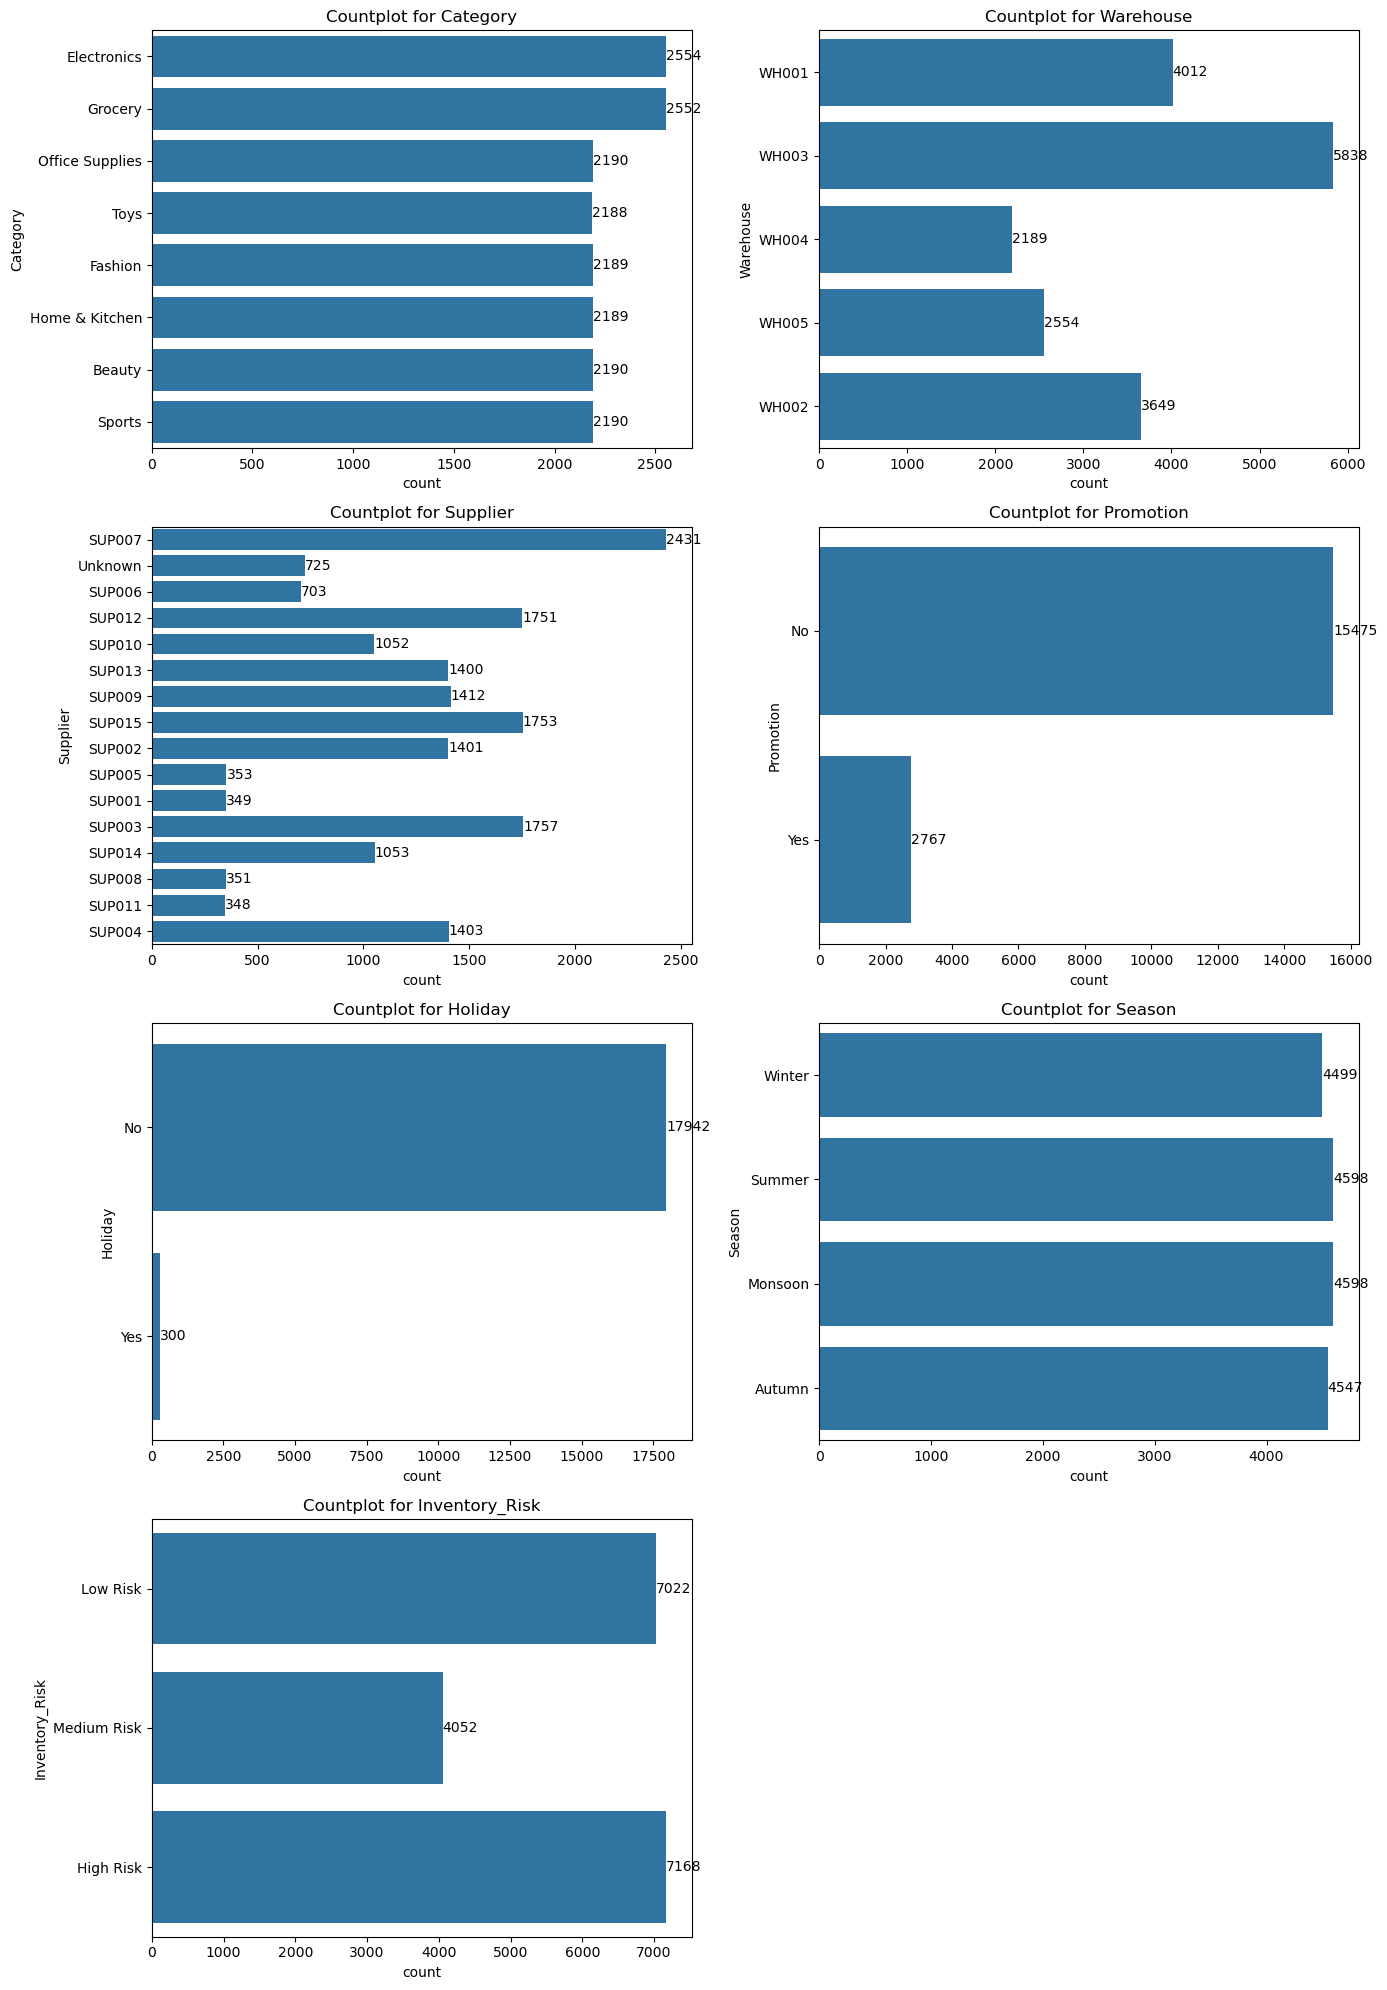

In [28]:
cols = cat_cols[2:]
plt.figure(figsize=(14,20))
for i in range(len(cols)):
    plt.subplot(4,2,i+1)
    ax = sns.countplot(data=df,y=cols[i])  
    ax.bar_label(ax.containers[0])
    plt.title(f'Countplot for {cols[i]}')
plt.tight_layout()
plt.show()

### Bivariate-Categorical-ategorical Countplot

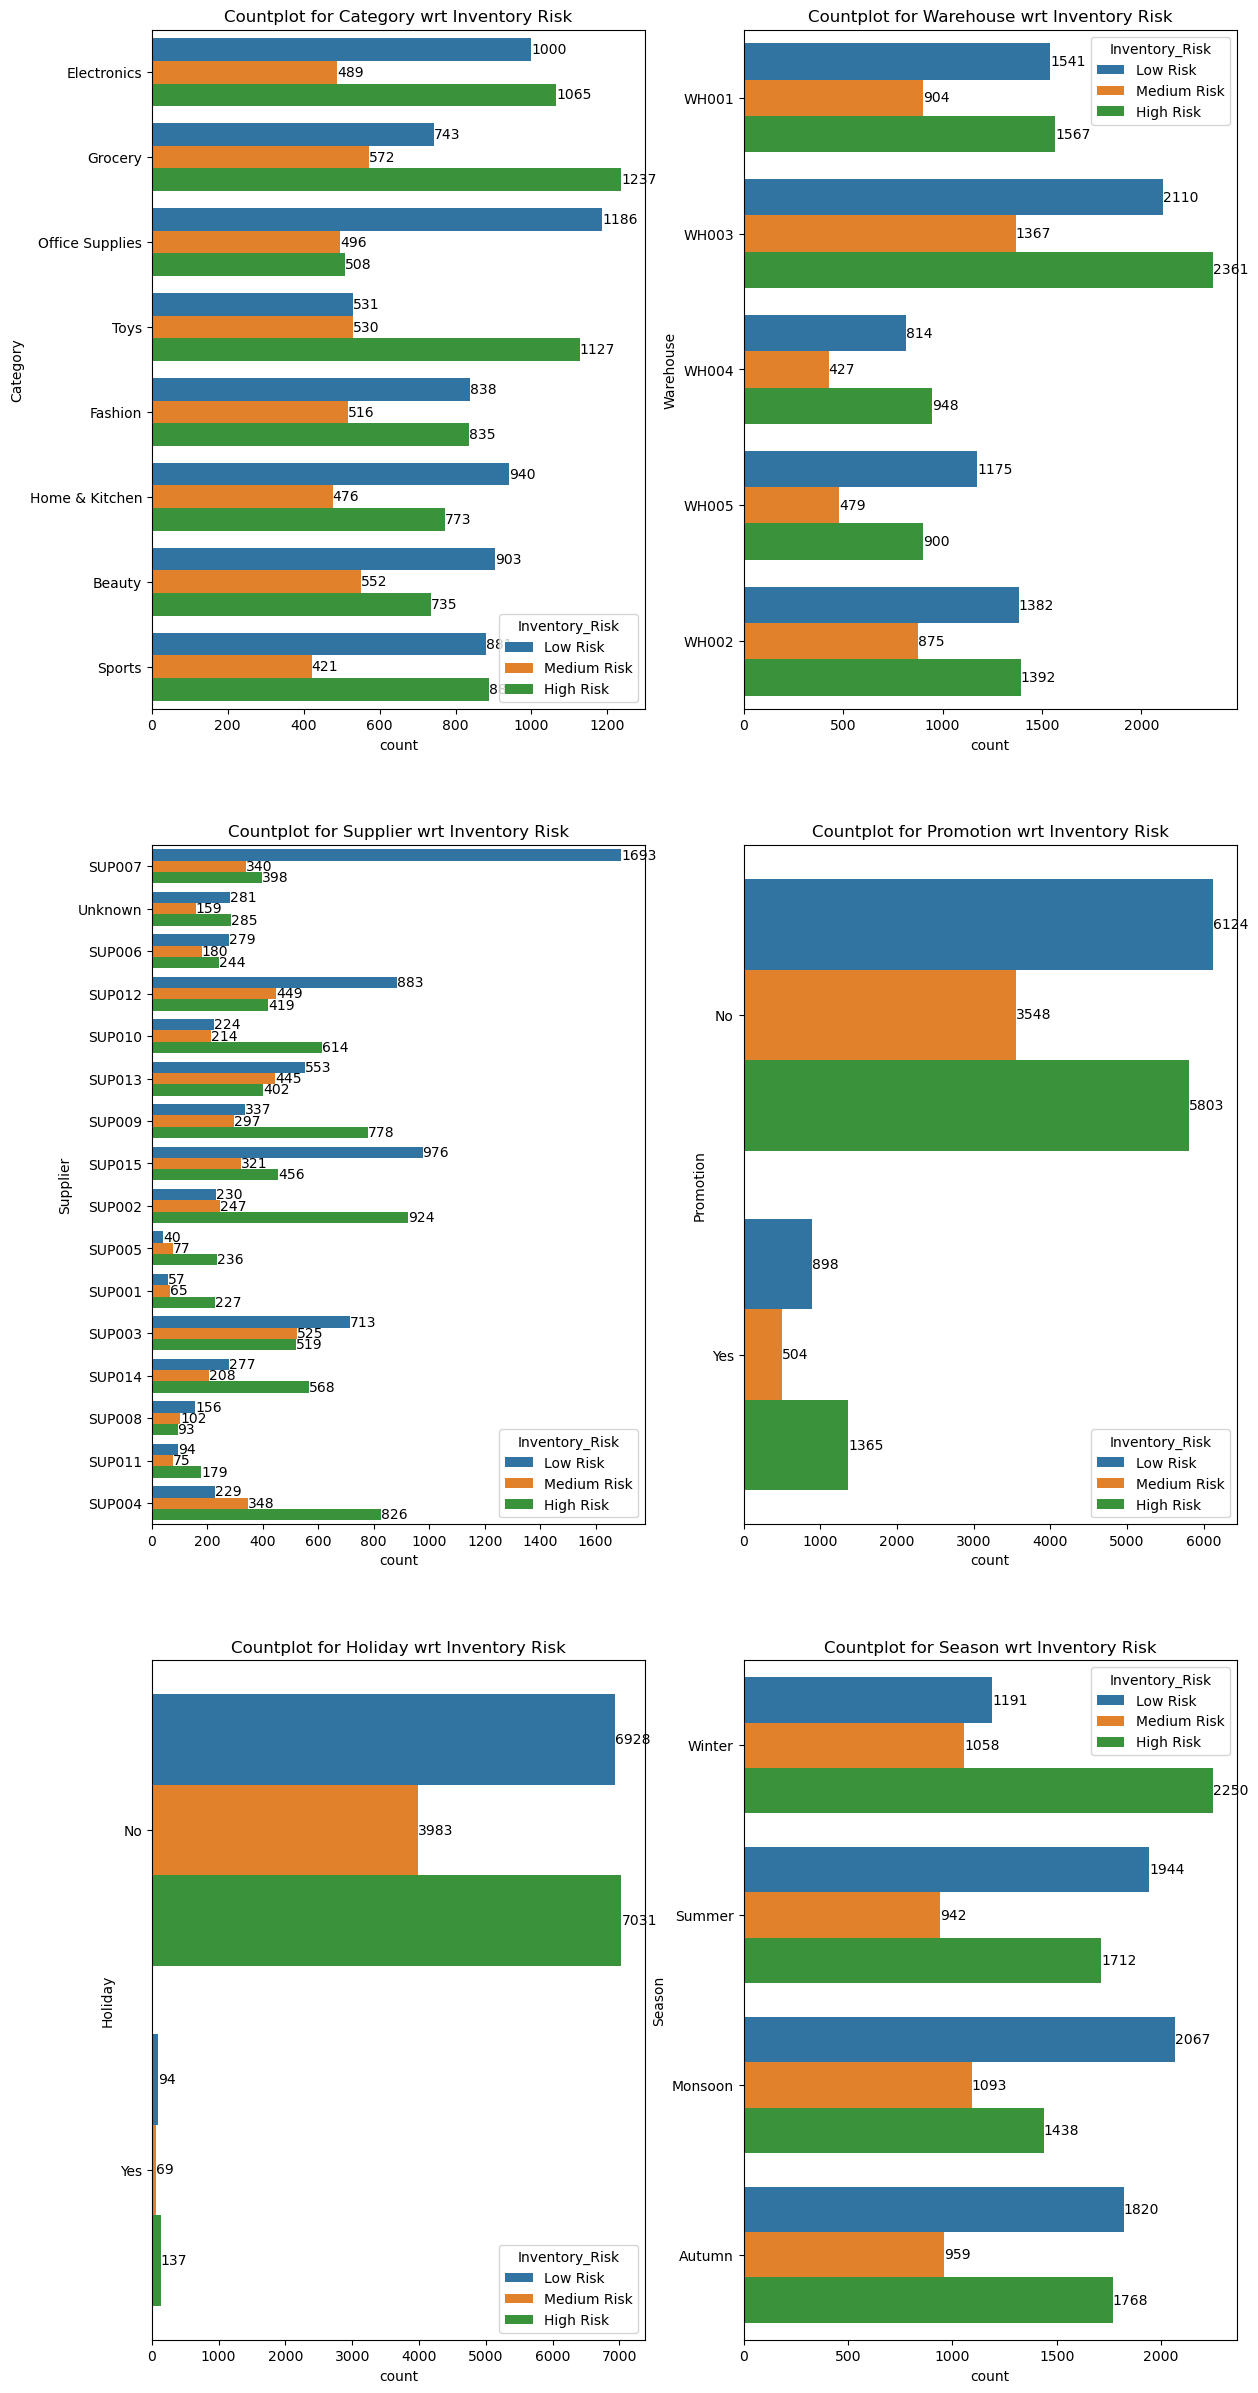

In [29]:
cols = cat_cols[2:-1]
plt.figure(figsize=(14,30))
for i in range(len(cols)):
    plt.subplot(3,2,i+1)
    ax = sns.countplot(data=df,y=cols[i],hue='Inventory_Risk')  
    ax.bar_label(ax.containers[0])
    ax.bar_label(ax.containers[1])
    ax.bar_label(ax.containers[2])
    plt.title(f'Countplot for {cols[i]} wrt Inventory Risk')
plt.tight_layout
plt.show()

### Univariate Numerical - Boxplot

In [30]:
num_cols

Index(['Date', 'Current_Stock', 'Reorder_Point', 'Safety_Stock',
       'Lead_Time_Days', 'Units_Sold', 'Unit_Price', 'Supplier_Reliability',
       'Days_of_Supply', 'Is_Reorder_Needed', 'Stock_Buffer', 'Month',
       'DayOfWeek', 'Is_Weekend', 'Risk_Score'],
      dtype='object')

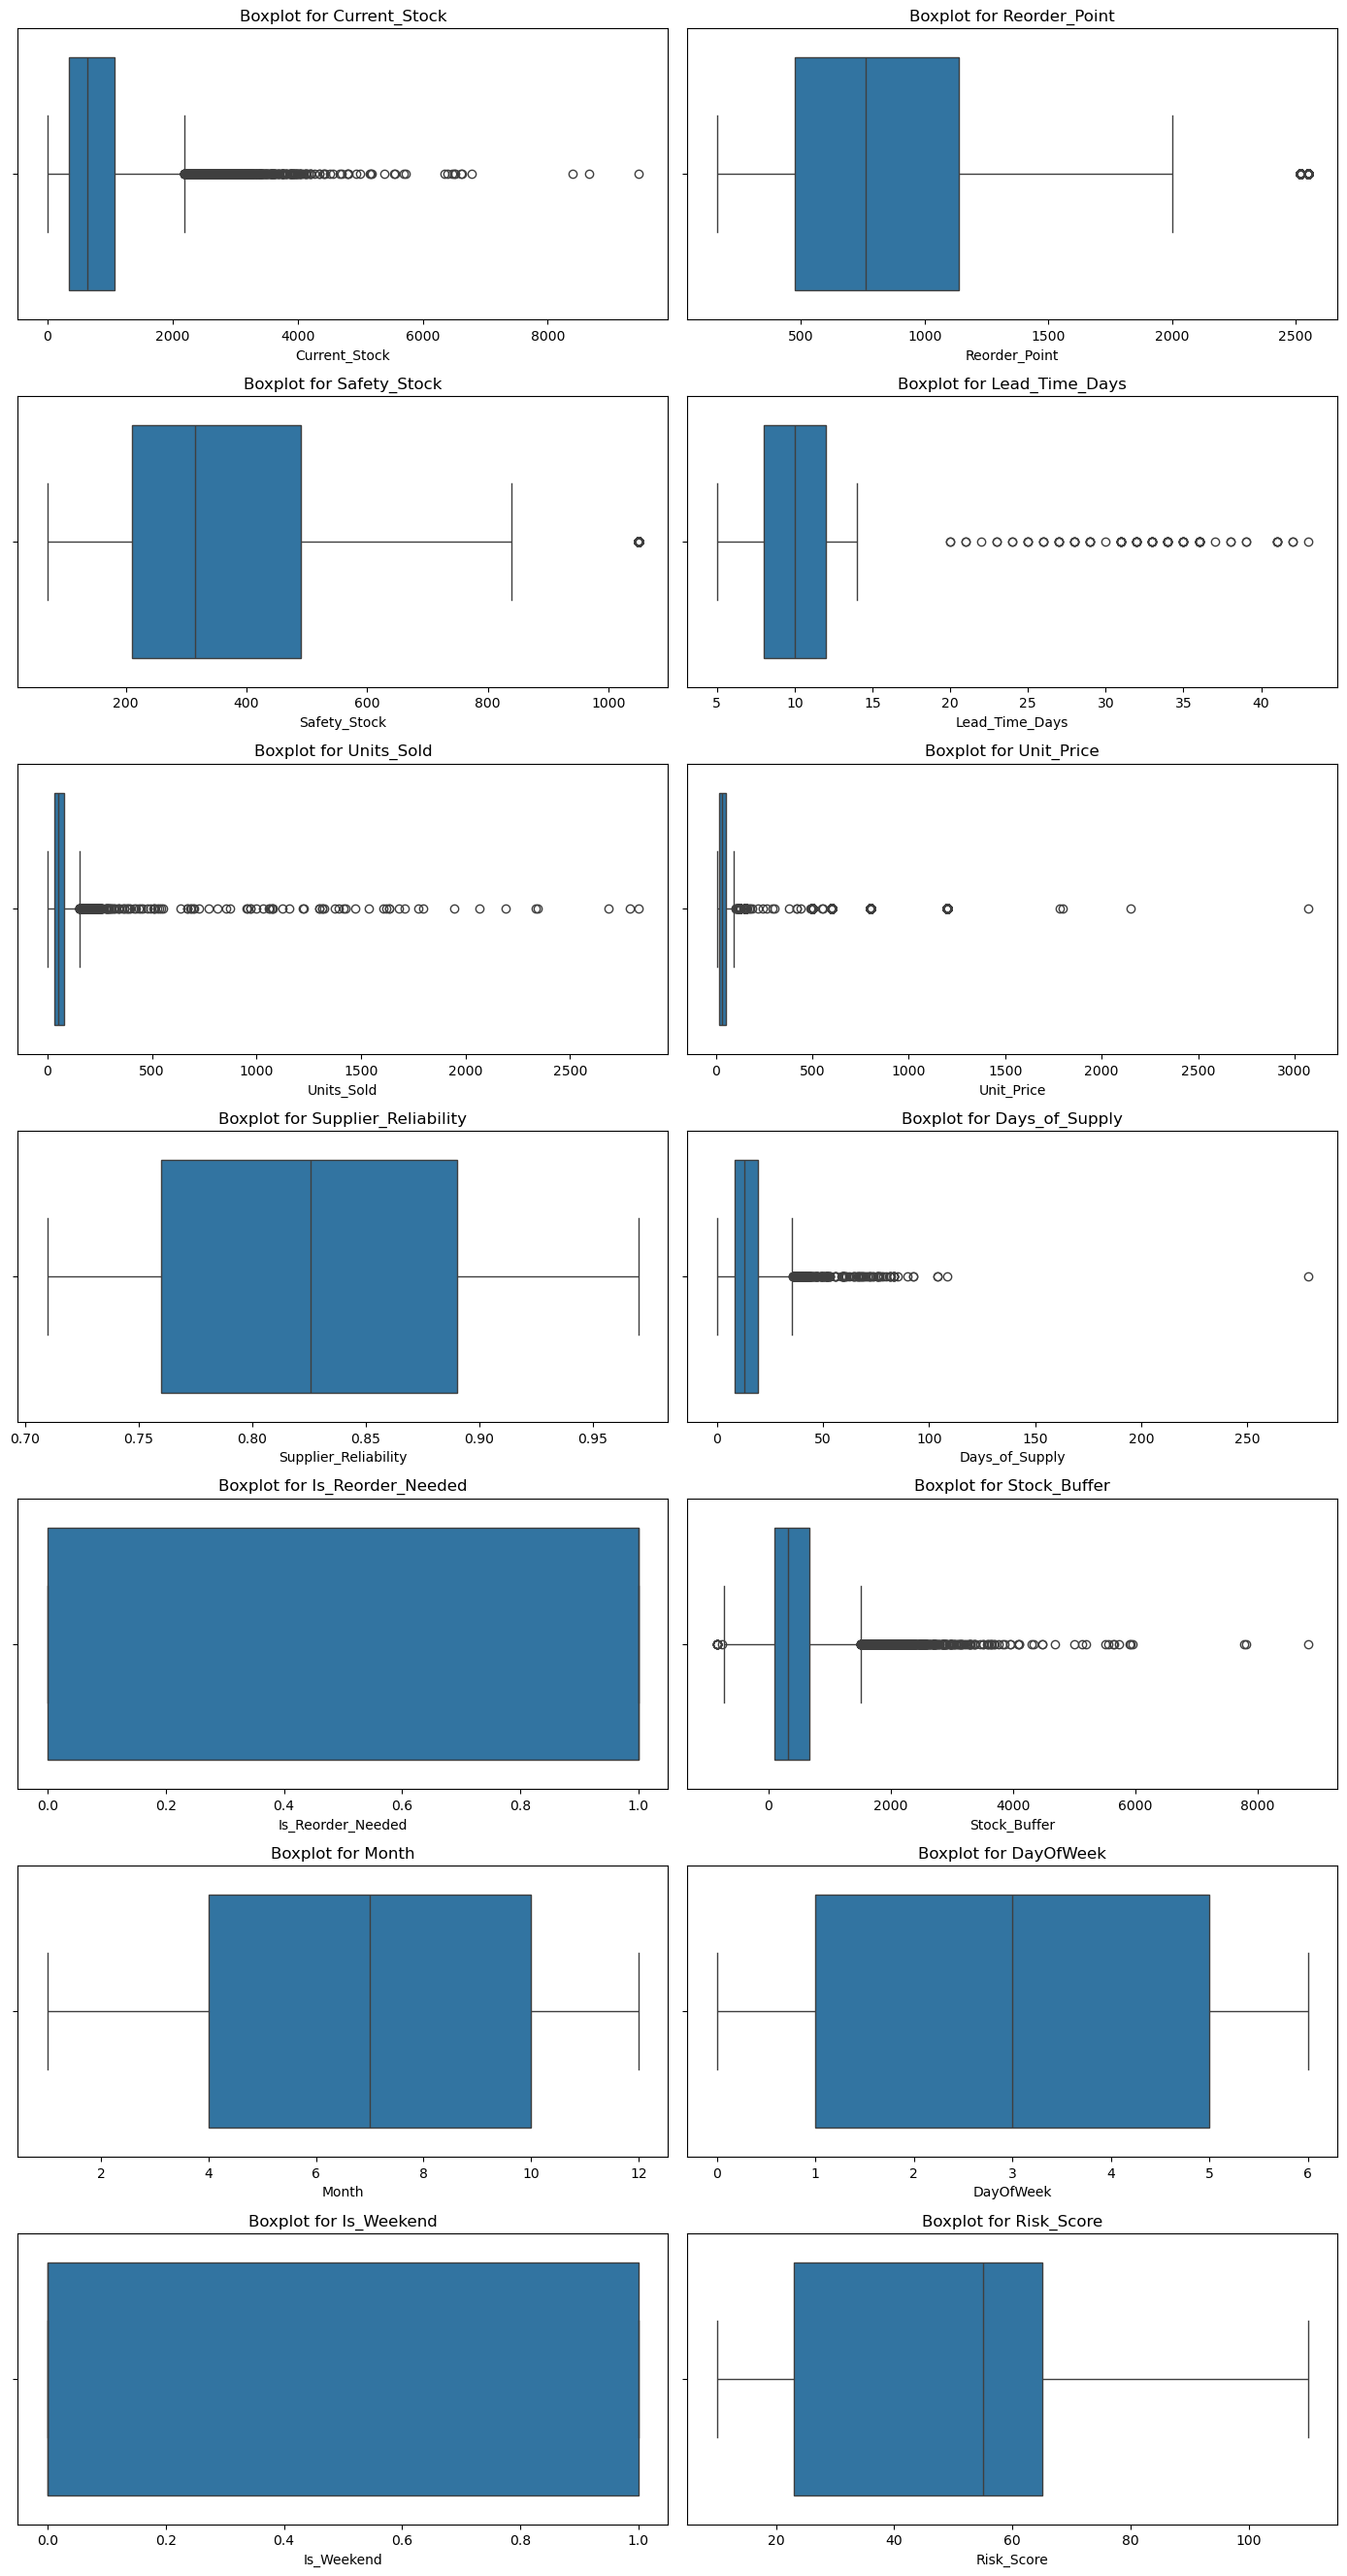

In [31]:
cols = num_cols[1:]
plt.figure(figsize=(14,30))  
for i in range(len(cols)): 
    plt.subplot(8,2,i+1)   
    sns.boxplot(data=df,x=cols[i])  
    plt.title(f'Boxplot for {cols[i]}')
plt.tight_layout()
plt.show()

## Outlier Treatment

In [32]:
a1 = df[num_cols[1:]].describe(percentiles=[0.01,0.02,0.05,0.95,0.98,0.99]).T  
a1 = a1.iloc[:,3:]  
a1

,min,1%,2%,5%,50%,95%,98%,99%,max
Current_Stock,0.00,0.00,44.000000,113.000000,632.000000,2051.950000,2718.900000,3205.000000,9451.000
Reorder_Point,160.00,160.00,190.000000,210.000000,760.000000,2000.000000,2525.400000,2550.000000,2550.000
Safety_Stock,70.00,70.00,70.000000,84.000000,315.000000,840.000000,877.800000,1050.000000,1050.000
Lead_Time_Days,5.00,5.00,5.000000,5.000000,10.000000,14.000000,14.000000,14.000000,43.000
Units_Sold,0.00,8.00,10.000000,13.000000,53.000000,142.000000,175.000000,204.000000,2827.000
Unit_Price,5.00,5.00,5.000000,8.000000,30.000000,600.000000,1200.000000,1200.000000,3069.000
Supplier_Reliability,0.71,0.71,0.710000,0.710000,0.825532,0.970000,0.970000,0.970000,0.970
Days_of_Supply,0.00,0.00,0.947268,2.867813,13.068116,27.567551,31.930179,36.351212,278.625
Is_Reorder_Needed,0.00,0.00,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000
Stock_Buffer,-840.00,-350.00,-261.180000,-107.000000,316.000000,1433.000000,1931.180000,2360.180000,8821.000


### Oulier Treatment Clipping Method

In [33]:
df['Stock_Buffer'] = np.where(df['Stock_Buffer']<df['Stock_Buffer'].quantile(0.01),
                              df['Stock_Buffer'].quantile(0.01),df['Stock_Buffer'])

In [34]:
right_sk_cols = ['Current_Stock','Lead_Time_Days','Units_Sold','Unit_Price','Days_of_Supply','Stock_Buffer']

In [35]:
for i in right_sk_cols:
    upper = df[i].quantile(0.99)
    df[i] = np.where(df[i]>upper, upper, df[i])

## Encoding 

In [36]:
cat_cols

Index(['Product_ID', 'Product_Name', 'Category', 'Warehouse', 'Supplier',
       'Promotion', 'Holiday', 'Season', 'Inventory_Risk'],
      dtype='object')

### Dummy Varibale Creation

In [37]:
encode_cols = ['Category', 'Warehouse', 'Promotion', 'Holiday', 'Season']

In [38]:
df_dummies = pd.get_dummies(data=df,columns=encode_cols, dtype=int,drop_first=True)
print(df_dummies.shape)

(18242, 35)


In [39]:
df_dummies.head()

,Date,Product_ID,Product_Name,Supplier,Current_Stock,Reorder_Point,Safety_Stock,Lead_Time_Days,Units_Sold,Unit_Price,...,Category_Toys,Warehouse_WH002,Warehouse_WH003,Warehouse_WH004,Warehouse_WH005,Promotion_Yes,Holiday_Yes,Season_Monsoon,Season_Summer,Season_Winter
0,2025-01-01,P001,Smartphone X,SUP007,630.0,240.0,140,5.0,30.0,800.0,...,0,0,0,0,0,0,0,0,0,1
1,2025-01-02,P001,Smartphone X,SUP007,604.0,240.0,140,5.0,26.0,800.0,...,0,0,0,0,0,0,0,0,0,1
2,2025-01-03,P001,Smartphone X,SUP007,577.0,240.0,140,5.0,27.0,800.0,...,0,0,0,0,0,0,0,0,0,1
3,2025-01-04,P001,Smartphone X,SUP007,543.0,240.0,140,5.0,34.0,800.0,...,0,0,0,0,0,0,0,0,0,1
4,2025-01-05,P001,Smartphone X,SUP007,488.0,240.0,140,5.0,55.0,800.0,...,0,0,0,0,0,1,0,0,0,1


### Label Encoding for Inventory_Risk

In [40]:
from sklearn.preprocessing import LabelEncoder

In [41]:
le = LabelEncoder()
df_dummies['Inventory_Risk'] = le.fit_transform(df_dummies['Inventory_Risk'])

In [42]:
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'High Risk': 0, 'Low Risk': 1, 'Medium Risk': 2}


## Select x and y

In [43]:
x = df_dummies.drop(['Date','Product_ID','Product_Name','Supplier', 'Inventory_Risk'], axis=1)
y = df_dummies['Inventory_Risk']
print(x.shape)
print(y.shape)

(18242, 30)
(18242,)


## Split Data Into Train and Test

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(12769, 30) (5473, 30)
(12769,) (5473,)


## Function to Evaluate Model Performance

In [46]:
from sklearn.metrics import *

In [47]:
def eval_model(x_train, x_test, y_train, y_test, model, mname):
    model.fit(x_train, y_train)
    ypred = model.predict(x_test)
    train_acc = model.score(x_train, y_train)
    test_acc = model.score(x_test, y_test)
    precision = precision_score(y_test, ypred, average=None)
    recall = recall_score(y_test, ypred, average=None)
    f1 = f1_score(y_test, ypred, average=None)
    evals = {'Train_Score': train_acc, 'Test_Score': test_acc, 
             'Pre0': precision[0], 'Rec0': recall[0], 'F1_Score0': f1[0],
             'Pre1': precision[1], 'Rec1': recall[1], 'F1_Score1': f1[1],
             'Pre2': precision[2], 'Rec2': recall[2], 'F1_Score2': f1[2]}
    
    eval_df = pd.DataFrame(evals, index=[mname])
    return ypred, eval_df

## Model Training

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

### Logistic Regression

In [58]:
lr = LogisticRegression(max_iter=100000)
ypred_lr, lr_df = eval_model(x_train, x_test, y_train, y_test, lr, "LogisticRegression")
lr_df

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 13353 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Train_Score,Test_Score,Pre0,Rec0,F1_Score0,Pre1,Rec1,F1_Score1,Pre2,Rec2,F1_Score2
LogisticRegression,0.9935,0.991412,0.996249,0.988372,0.992295,0.99715,0.996203,0.996676,0.973279,0.988487,0.980824


### Decision Tree Classifier

In [59]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=12)
ypred_dt, dt_df = eval_model(x_train, x_test, y_train, y_test, dt, "DT_Cls")
dt_df

,Train_Score,Test_Score,Pre0,Rec0,F1_Score0,Pre1,Rec1,F1_Score1,Pre2,Rec2,F1_Score2
DT_Cls,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Random Forest Classifier

In [60]:
rf = RandomForestClassifier(n_estimators=90, criterion='entropy', max_depth=10, min_samples_split=8)
ypred_rf, rf_df = eval_model(x_train, x_test, y_train, y_test, rf, "RF_Cls")
rf_df

,Train_Score,Test_Score,Pre0,Rec0,F1_Score0,Pre1,Rec1,F1_Score1,Pre2,Rec2,F1_Score2
RF_Cls,1.0,0.999269,1.0,1.0,1.0,1.0,0.998102,0.99905,0.996721,1.0,0.998358


In [61]:
all_eval = pd.concat([lr_df, dt_df, rf_df])

In [62]:
all_eval

,Train_Score,Test_Score,Pre0,Rec0,F1_Score0,Pre1,Rec1,F1_Score1,Pre2,Rec2,F1_Score2
LogisticRegression,0.9935,0.991412,0.996249,0.988372,0.992295,0.99715,0.996203,0.996676,0.973279,0.988487,0.980824
DT_Cls,1.0000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
RF_Cls,1.0000,0.999269,1.000000,1.000000,1.000000,1.00000,0.998102,0.999050,0.996721,1.000000,0.998358


## Saving Model

In [63]:
import pickle

In [64]:
pickle.dump(lr,open('Logistic_Regression.pkl','wb'))
pickle.dump(rf,open('Random_Forest.pkl','wb'))
pickle.dump(dt,open('Decision_Tree.pkl','wb'))

In [65]:
x_train.columns

Index(['Current_Stock', 'Reorder_Point', 'Safety_Stock', 'Lead_Time_Days',
       'Units_Sold', 'Unit_Price', 'Supplier_Reliability', 'Days_of_Supply',
       'Is_Reorder_Needed', 'Stock_Buffer', 'Month', 'DayOfWeek', 'Is_Weekend',
       'Risk_Score', 'Category_Electronics', 'Category_Fashion',
       'Category_Grocery', 'Category_Home & Kitchen',
       'Category_Office Supplies', 'Category_Sports', 'Category_Toys',
       'Warehouse_WH002', 'Warehouse_WH003', 'Warehouse_WH004',
       'Warehouse_WH005', 'Promotion_Yes', 'Holiday_Yes', 'Season_Monsoon',
       'Season_Summer', 'Season_Winter'],
      dtype='object')

In [66]:
pd.set_option('display.max_columns', None)
x_train.describe()

,Current_Stock,Reorder_Point,Safety_Stock,Lead_Time_Days,Units_Sold,Unit_Price,Supplier_Reliability,Days_of_Supply,Is_Reorder_Needed,Stock_Buffer,Month,DayOfWeek,Is_Weekend,Risk_Score,Category_Electronics,Category_Fashion,Category_Grocery,Category_Home & Kitchen,Category_Office Supplies,Category_Sports,Category_Toys,Warehouse_WH002,Warehouse_WH003,Warehouse_WH004,Warehouse_WH005,Promotion_Yes,Holiday_Yes,Season_Monsoon,Season_Summer,Season_Winter
count,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000,12769.000000
mean,802.622562,880.720182,359.595740,9.893414,61.809539,96.276529,0.819651,13.966262,0.551962,444.468145,6.539275,2.979717,0.279975,49.670452,0.141045,0.118255,0.140340,0.120135,0.118647,0.120370,0.121544,0.203227,0.316470,0.121858,0.139165,0.152400,0.016211,0.254131,0.250059,0.245360
std,626.941470,571.567636,212.768151,2.888649,40.392819,216.391719,0.088081,7.675514,0.497312,492.866931,3.444018,1.993798,0.449004,28.585052,0.348081,0.322923,0.347353,0.325132,0.323385,0.325406,0.326772,0.402415,0.465117,0.327134,0.346132,0.359423,0.126292,0.435389,0.433064,0.430317
min,0.000000,160.000000,70.000000,5.000000,0.000000,5.000000,0.710000,0.000000,0.000000,-350.000000,1.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,341.000000,475.000000,210.000000,8.000000,33.000000,18.000000,0.760000,8.113924,0.000000,105.000000,4.000000,1.000000,0.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,639.000000,760.000000,315.000000,10.000000,53.000000,30.000000,0.780000,13.117647,1.000000,319.000000,7.000000,3.000000,0.000000,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1079.000000,1140.000000,490.000000,12.000000,81.000000,50.000000,0.890000,19.166667,1.000000,667.000000,10.000000,5.000000,1.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,3205.000000,2550.000000,1050.000000,14.000000,204.000000,1200.000000,0.970000,36.351212,1.000000,2360.180000,12.000000,6.000000,1.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [67]:
df['Category'].value_counts()

Category
Electronics        2554
Grocery            2552
Office Supplies    2190
Beauty             2190
Sports             2190
Fashion            2189
Home & Kitchen     2189
Toys               2188
Name: count, dtype: int64